## Manhattan Plot of PCA-Based Association Analysis (PCA-GWAS)

In [0]:


from IPython.display import display, clear_output
import os
import re
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import pandas as pd
import numpy as np


# manhatan_old_pca trait

In [0]:
spark.sql("SELECT * FROM bmqg.gwas.run_local_20260313_old LIMIT 5").display()

# ---------- Extract chromosome number ----------
def extract_chr(chrom):
    match = re.search(r"ch(\d+)", str(chrom))
    return int(match.group(1)) if match else 0

# ---------- Manhattan plot ----------
def plot_manhattan(df_trait, trait_name):

    plt.figure(figsize=(12,5))

    colors = ["#1f77b4", "#ff7f0e"]

    x_vals = []
    x_labels = []
    last_pos = 0
    color_index = 0

    for chrom in sorted(df_trait["chr"].unique()):
        sub = df_trait[df_trait["chr"] == chrom]

        x = sub["start"].values + last_pos

        plt.scatter(x, sub["-log10p"].values, s=6, color=colors[color_index])

        x_vals.append(x.mean())
        x_labels.append(str(chrom))

        last_pos = x.max()
        color_index = 1 - color_index

    #  FIX: significance line 
    plt.axhline(6, color='red', linestyle='--', label='p = 1e-6')

    plt.xticks(x_vals, x_labels)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p-value)")
    plt.title(f"Manhattan Plot - {trait_name}")

    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------- Run safely per trait ----------
traits = ["PC1", "PC2", "PC3", "PC4", "PC5"]

for trait in traits:
    print("Processing:", trait)

    df = spark.sql(f"""
    SELECT chrom, start, p_wald
    FROM bmqg.gwas.run_local_20260313_old
    WHERE trait = '{trait}'
    """).toPandas()

    # ---------- Clean ----------
    df = df.dropna(subset=["p_wald"])

    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["p_wald"] = pd.to_numeric(df["p_wald"], errors="coerce")

    df = df.dropna(subset=["start", "p_wald"])

    df["-log10p"] = -np.log10(df["p_wald"])

    df["chr"] = df["chrom"].apply(extract_chr)

    df = df.sort_values(["chr", "start"]).reset_index(drop=True)

    # ---------- Plot ----------
    plot_manhattan(df, trait)

com.databricks.backend.common.rpc.DriverStoppedException: Driver down cause: driver state change (exit code: 137)
	at com.databricks.spark.chauffeur.ChauffeurState.processDriverStateChange(ChauffeurState.scala:310)
	at com.databricks.spark.chauffeur.Chauffeur.onDriverStateChange(Chauffeur.scala:2035)
	at com.databricks.spark.chauffeur.Chauffeur.$anonfun$driverStateOpt$1(Chauffeur.scala:240)
	at com.databricks.spark.chauffeur.Chauffeur.$anonfun$driverStateOpt$1$adapted(Chauffeur.scala:240)
	at com.databricks.spark.chauffeur.DriverDaemonMonitorImpl.$anonfun$goToStopped$1(DriverDaemonMonitorImpl.scala:401)
	at com.databricks.spark.chauffeur.DriverDaemonMonitorImpl.$anonfun$goToStopped$1$adapted(DriverDaemonMonitorImpl.scala:401)
	at scala.collection.immutable.List.foreach(List.scala:333)
	at com.databricks.spark.chauffeur.DriverDaemonMonitorImpl.goToStopped(DriverDaemonMonitorImpl.scala:401)
	at com.databricks.spark.chauffeur.DriverDaemonMonitorImpl.monitorDriver(DriverDaemonMonitorImpl.s

## Genome-Wide Association Analysis for PC3: Identification of Significant SNPs

In [0]:


#  Load PC3
df = spark.sql("""
SELECT rs, chrom, start, p_wald
FROM bmqg.gwas.run_local_20260313_old
WHERE trait = 'PC3'
""").toPandas()

# ---------- Clean ----------
df["start"] = pd.to_numeric(df["start"], errors="coerce")
df["p_wald"] = pd.to_numeric(df["p_wald"], errors="coerce")
df = df.dropna(subset=["start", "p_wald"])

df["-log10p"] = -np.log10(df["p_wald"])

# ---------- Extract chr ----------
def extract_chr(chrom):
    import re
    m = re.search(r"ch(\d+)", str(chrom))
    return int(m.group(1)) if m else 0

df["chr"] = df["chrom"].apply(extract_chr)


hits = df[df["-log10p"] >= 6]


hits = hits.sort_values(["chr", "start"])

print("Number of significant SNPs:", len(hits))
hits

Number of significant SNPs: 105


,rs,chrom,start,p_wald,-log10p,chr
3809172,112259_112260_112265_112274,ST4.03ch03,300000,9.015527e-07,6.045009,3
11125625,112258_112260_112265_112274,ST4.03ch03,300000,9.015527e-07,6.045009,3
2200490,219602_0_0_0,ST4.03ch04,70300000,1.633956e-07,6.786760,4
5201093,219599_219602_0_0,ST4.03ch04,70300000,5.853848e-07,6.232559,4
5267512,219600_219602_0_0,ST4.03ch04,70300000,5.853848e-07,6.232559,4
...,...,...,...,...,...,...
4870671,258259_258263_258264_258269,ST4.03ch05,51250000,8.855945e-07,6.052765,5
11614736,258259_258262_258264_258269,ST4.03ch05,51250000,8.855945e-07,6.052765,5
12608534,258259_258262_258264_258270,ST4.03ch05,51250000,8.855945e-07,6.052765,5
9745022,258303_258305_258306_258316,ST4.03ch05,51300000,3.918653e-07,6.406863,5


## Genome-Wide Association Analysis for PC2: Identification of Significant SNPs

In [0]:


#  Load 
df = spark.sql("""
SELECT rs, chrom, start, p_wald
FROM bmqg.gwas.run_local_20260313_old
WHERE trait = 'PC2'
""").toPandas()

# ---------- Clean ----------
df["start"] = pd.to_numeric(df["start"], errors="coerce")
df["p_wald"] = pd.to_numeric(df["p_wald"], errors="coerce")
df = df.dropna(subset=["start", "p_wald"])

df["-log10p"] = -np.log10(df["p_wald"])

# ---------- Extract chr ----------
def extract_chr(chrom):
    import re
    m = re.search(r"ch(\d+)", str(chrom))
    return int(m.group(1)) if m else 0

df["chr"] = df["chrom"].apply(extract_chr)


hits = df[df["-log10p"] >= 6]


hits = hits.sort_values(["chr", "start"])

print("Number of significant SNPs:", len(hits))
hits

Number of significant SNPs: 22


,rs,chrom,start,p_wald,-log10p,chr
2499700,337179_337180_337187_337191,ST4.03ch07,44600000,9.403247e-07,6.026722,7
10191621,411676_411681_411683_411684,ST4.03ch09,30900000,8.863897e-07,6.052376,9
11031968,411675_411681_411683_411684,ST4.03ch09,30900000,8.863897e-07,6.052376,9
1756777,411724_411731_411733_411734,ST4.03ch09,30950000,7.661721e-07,6.115674,9
2292940,411723_411730_411733_411734,ST4.03ch09,30950000,6.742121e-07,6.171204,9
4376879,411723_411731_411733_411734,ST4.03ch09,30950000,6.742121e-07,6.171204,9
9721442,411724_411730_411733_411734,ST4.03ch09,30950000,7.661721e-07,6.115674,9
1932754,411763_411768_411770_411771,ST4.03ch09,31000000,7.337046e-07,6.134479,9
370995,411856_411863_411865_411867,ST4.03ch09,31100000,8.233755e-07,6.084403,9
715816,411862_411865_411866_411867,ST4.03ch09,31100000,1.702711e-07,6.768859,9


chr3 → ~0.3 Mb

chr4 → ~70.3 Mb

chr5 → ~51.2–51.3 Mb 


chr7 → ~44.6 Mb

chr9 → ~30.9–31.5 Mb

# manhatan_new_pca trait

Processing: PC1


/root/.ipykernel/39834/command-5343370928565292-2423867299:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


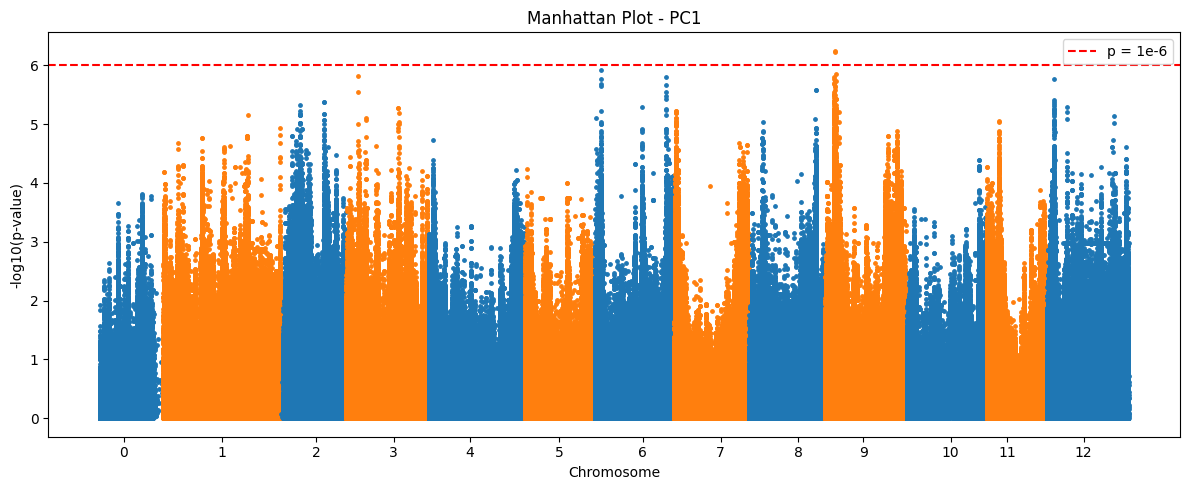

Processing: PC2


/root/.ipykernel/39834/command-5343370928565292-2423867299:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


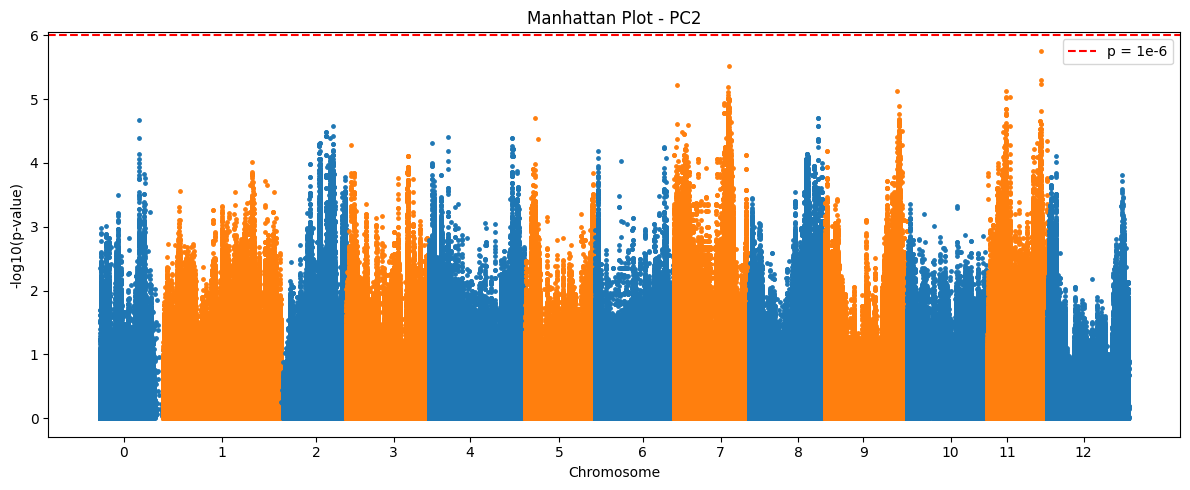

Processing: PC3


/root/.ipykernel/39834/command-5343370928565292-2423867299:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


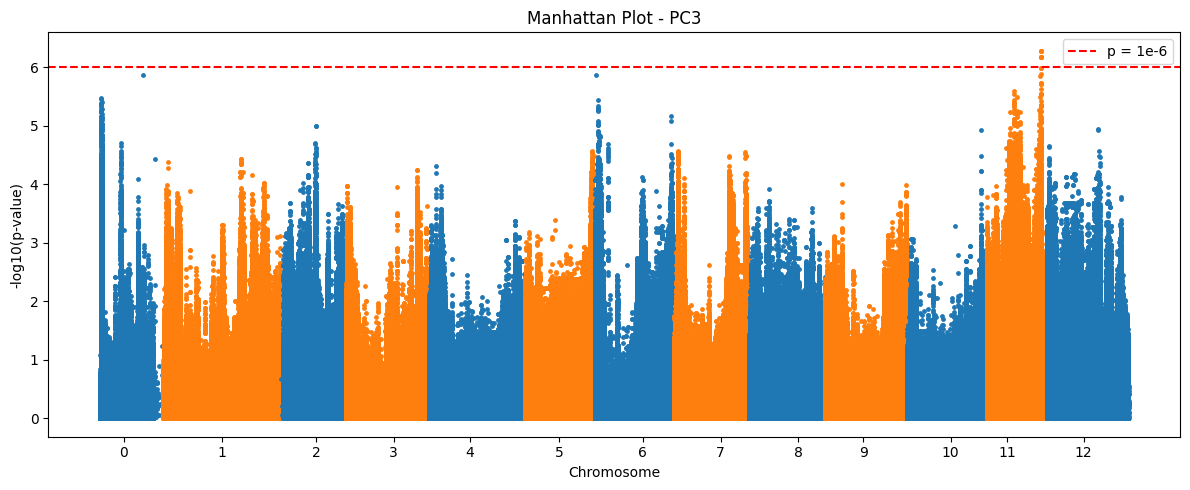

Processing: PC4


/root/.ipykernel/39834/command-5343370928565292-2423867299:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


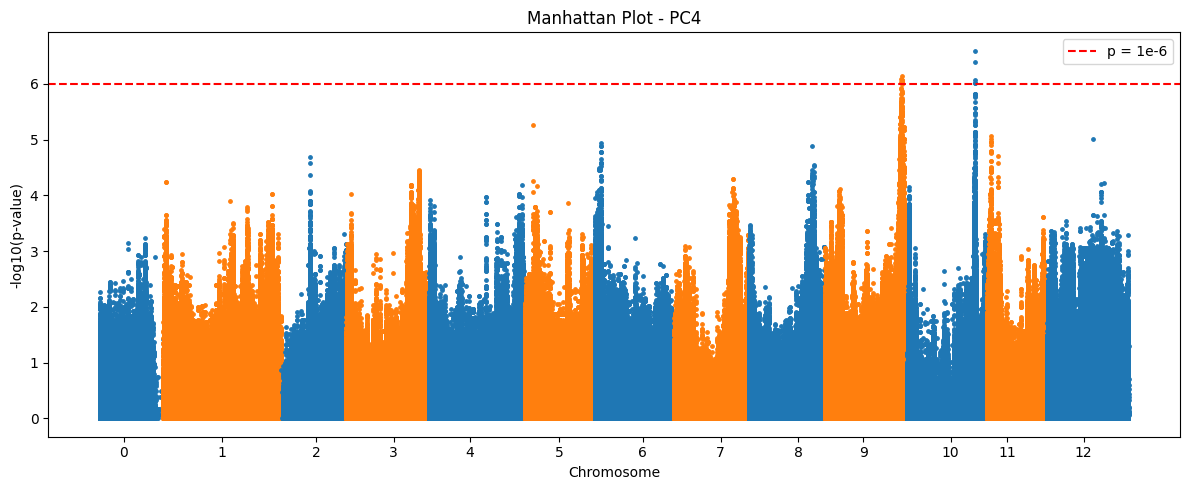

Processing: PC5


/root/.ipykernel/39834/command-5343370928565292-2423867299:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


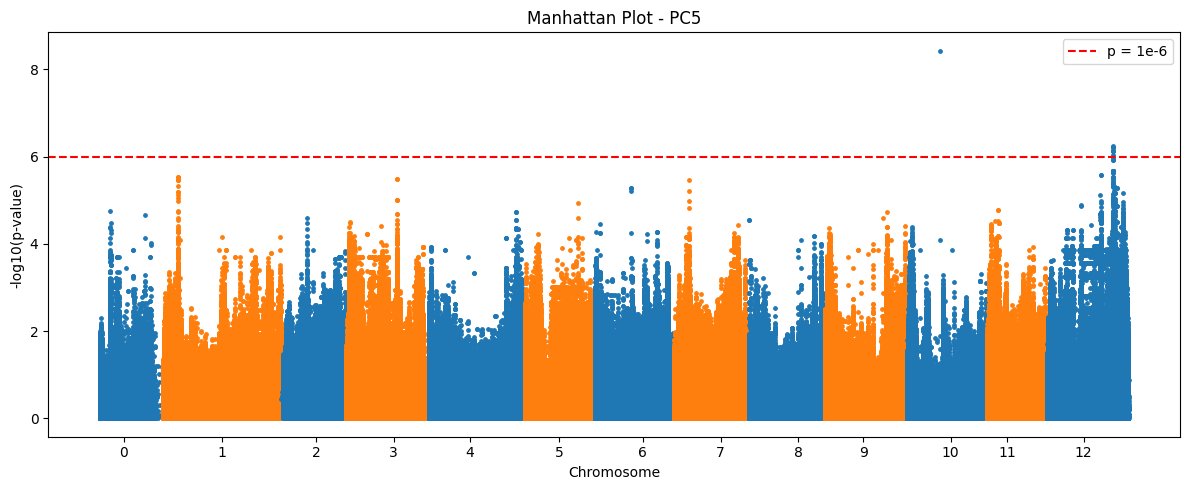

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---------- Extract chromosome number ----------
def extract_chr(chrom):
    match = re.search(r"ch(\d+)", str(chrom))
    return int(match.group(1)) if match else 0

# ---------- Manhattan plot ----------
def plot_manhattan(df_trait, trait_name):

    plt.figure(figsize=(12,5))

    colors = ["#1f77b4", "#ff7f0e"]

    x_vals = []
    x_labels = []
    last_pos = 0
    color_index = 0

    for chrom in sorted(df_trait["chr"].unique()):
        sub = df_trait[df_trait["chr"] == chrom]

        x = sub["start"].values + last_pos

        plt.scatter(x, sub["-log10p"].values, s=6, color=colors[color_index])

        x_vals.append(x.mean())
        x_labels.append(str(chrom))

        last_pos = x.max()
        color_index = 1 - color_index

    #  FIX: significance line 
    plt.axhline(6, color='red', linestyle='--', label='p = 1e-6')

    plt.xticks(x_vals, x_labels)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p-value)")
    plt.title(f"Manhattan Plot - {trait_name}")

    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------- Run safely per trait ----------
traits = ["PC1", "PC2", "PC3", "PC4", "PC5"]

for trait in traits:
    print("Processing:", trait)

    df = spark.sql(f"""
    SELECT chrom, start, p_wald
    FROM bmqg.gwas.run_local_20260314_new
    WHERE trait = '{trait}'
    """).toPandas()

    # ---------- Clean ----------
    df = df.dropna(subset=["p_wald"])

    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["p_wald"] = pd.to_numeric(df["p_wald"], errors="coerce")

    df = df.dropna(subset=["start", "p_wald"])

    df["-log10p"] = -np.log10(df["p_wald"])

    df["chr"] = df["chrom"].apply(extract_chr)

    df = df.sort_values(["chr", "start"]).reset_index(drop=True)

    # ---------- Plot ----------
    plot_manhattan(df, trait)

## Genome-Wide Association Analysis for PC3_newharvested: Identification of Significant SNPs

In [0]:


# ---------- Load PC3 ----------
df = spark.sql("""
SELECT rs, chrom, start, p_wald
FROM bmqg.gwas.run_local_20260314_new
WHERE trait = 'PC3'
""").toPandas()

# ---------- Clean ----------
df["start"] = pd.to_numeric(df["start"], errors="coerce")
df["p_wald"] = pd.to_numeric(df["p_wald"], errors="coerce")
df = df.dropna(subset=["start", "p_wald"])

df["-log10p"] = -np.log10(df["p_wald"])

# ---------- Extract chromosome ----------
def extract_chr(chrom):
    m = re.search(r"ch(\d+)", str(chrom))
    return int(m.group(1)) if m else 0

df["chr"] = df["chrom"].apply(extract_chr)

# ---------- Filter significant SNPs ----------
hits = df[df["-log10p"] >= 6]

# ---------- Sort ----------
hits = hits.sort_values(["chr", "start"])

# ---------- Output ----------
print("Number of significant SNPs:", len(hits))
hits

Number of significant SNPs: 11


,rs,chrom,start,p_wald,-log10p,chr
2135491,519847_519848_519851_519854,ST4.03ch11,40650000,5.202585e-07,6.283781,11
4955199,519847_519848_519850_519854,ST4.03ch11,40650000,5.202585e-07,6.283781,11
5294561,519848_519851_519854_0,ST4.03ch11,40650000,6.575211e-07,6.182090,11
6419075,519847_519853_519854_0,ST4.03ch11,40650000,5.202585e-07,6.283781,11
7020499,519848_519853_519854_0,ST4.03ch11,40650000,5.202585e-07,6.283781,11
7699669,519847_519850_519854_0,ST4.03ch11,40650000,6.575211e-07,6.182090,11
11515729,519848_519850_519854_0,ST4.03ch11,40650000,6.575211e-07,6.182090,11
11989909,519847_519851_519854_0,ST4.03ch11,40650000,6.575211e-07,6.182090,11
12453312,519853_519854_0_0,ST4.03ch11,40650000,6.575211e-07,6.182090,11
5603865,519889_519892_519894_0,ST4.03ch11,40700000,6.575211e-07,6.182090,11


## Genome-Wide Association Analysis for PC4_newharvested: Identification of Significant SNPs


In [0]:


#  Load 
df = spark.sql("""
SELECT rs, chrom, start, p_wald
FROM bmqg.gwas.run_local_20260314_new
WHERE trait = 'PC4'
""").toPandas()

# ---------- Clean ----------
df["start"] = pd.to_numeric(df["start"], errors="coerce")
df["p_wald"] = pd.to_numeric(df["p_wald"], errors="coerce")
df = df.dropna(subset=["start", "p_wald"])

df["-log10p"] = -np.log10(df["p_wald"])

# ---------- Extract chr ----------
def extract_chr(chrom):
    import re
    m = re.search(r"ch(\d+)", str(chrom))
    return int(m.group(1)) if m else 0

df["chr"] = df["chrom"].apply(extract_chr)


hits = df[df["-log10p"] >= 6]


hits = hits.sort_values(["chr", "start"])

print("Number of significant SNPs:", len(hits))
hits

Number of significant SNPs: 13


,rs,chrom,start,p_wald,-log10p,chr
3918578,432995_432997_433000_433009,ST4.03ch09,56650000,9.314700e-07,6.030831,9
482648,433085_433086_433088_433092,ST4.03ch09,56750000,8.210676e-07,6.085621,9
139032,433836_433837_433840_433852,ST4.03ch09,57750000,9.194998e-07,6.036449,9
2384863,433833_433840_433845_433852,ST4.03ch09,57750000,9.984284e-07,6.000683,9
3994356,433836_433838_433840_433852,ST4.03ch09,57750000,9.194998e-07,6.036449,9
7258289,433836_433840_433845_433852,ST4.03ch09,57750000,7.294229e-07,6.137021,9
11134554,433833_433838_433840_433852,ST4.03ch09,57750000,8.385980e-07,6.076447,9
11554683,433833_433837_433840_433852,ST4.03ch09,57750000,8.385980e-07,6.076447,9
2654170,485488_485498_0_0,ST4.03ch10,50750000,4.078249e-07,6.389526,10
5727800,485487_485488_485498_0,ST4.03ch10,50750000,8.605920e-07,6.065203,10
